
# การดูดซึมข้อมูลระดับโลกด้วย HealDA

สร้างฟิลด์วิเคราะห์สภาพอากาศระดับโลกจากข้อมูลสังเกตดาวเทียมและข้อมูลสังเกตภาคพื้น

ตัวอย่างนี้สาธิตวิธีใช้โมเดลการดูดซึมข้อมูล HealDA เพื่อสร้างการวิเคราะห์สภาพอากาศทั่วโลกบนกริด HEALPix โดยใช้ทั้งข้อมูลสังเกตภาคพื้นแบบกระจัดกระจาย (conventional observations) และข้อมูลการแผ่รังสีจากดาวเทียมที่มาจากคลังข้อมูล NOAA UFS

ในตัวอย่างนี้มีการเปรียบเทียบ 3 กรณี: ใช้ข้อมูลสังเกตแบบ conventional เท่านั้น ใช้ข้อมูลดาวเทียมเท่านั้น และใช้ทั้งสองแบบร่วมกัน เพื่อให้เห็นผลกระทบของข้อมูลสังเกตแต่ละประเภท

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีโหลดและเริ่มต้นโมเดลการดูดซึมข้อมูล HealDA
- วิธีดึง DataFrame ของข้อมูลสังเกตแบบ conventional และข้อมูลสังเกตดาวเทียมจาก UFS
- วิธีรันโมเดลด้วยชุดข้อมูลสังเกตที่แตกต่างกัน
- วิธีเปรียบเทียบฟิลด์วิเคราะห์ที่ได้กับข้อมูล ERA5


In [1]:
# /// script
# dependencies = [
#   "earth2studio[da-healda] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
ตัวอย่างนี้ต้องใช้คอมโพเนนต์ต่อไปนี้:

- โมเดลการดูดซึมข้อมูล: HealDA :py:class:`earth2studio.models.da.HealDA`.
- Datasource (conv): ข้อมูลสังเกต UFS แบบ conventional :py:class:`earth2studio.data.UFSObsConv`.
- Datasource (sat): ข้อมูลสังเกตดาวเทียมจาก UFS :py:class:`earth2studio.data.UFSObsSat`.

HealDA คือโมเดลการดูดซึมข้อมูลด้วยโครงข่ายประสาทที่ทำงานแบบ stateless โดยรับอินพุตเป็นข้อมูลสังเกตแบบ conventional เช่น radiosonde, สถานีผิวพื้น, GPS-RO และข้อมูลการแผ่รังสีจากดาวเทียม จากนั้นสร้างฟิลด์วิเคราะห์สภาพอากาศทั่วโลกแบบ one-shot บนกริด HEALPix-6



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from datetime import timedelta

import numpy as np
import torch
from loguru import logger
from tqdm import tqdm

logger.remove()
logger.add(lambda msg: tqdm.write(msg, end=""), colorize=True)

from earth2studio.data import NCAR_ERA5, UFSObsConv, UFSObsSat, fetch_dataframe
from earth2studio.models.da import HealDA

# โหลดmodel packageเริ่มต้น (ดาวน์โหลด checkpoint จาก HuggingFace)
# การตั้งค่า lat_lon=True จะบันทึกเอาต์พุต HEALPix ดั้งเดิมเป็นกริด lat-lon ปกติ
package = HealDA.load_default_package()
model = HealDA.load_model(package, lat_lon=True)
model = model.to("cuda:0")

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


## ดึงข้อสังเกต
ดึง DataFrames การสังเกตแบบธรรมดาและแบบดาวเทียมมาเป็นเวลาวิเคราะห์
แหล่งข้อมูล UFS ส่งคืน DataFrames แพนด้าที่ตรงกับสคีมาที่คาดไว้
:py:meth:`HealDA.input_coords`.  เราใช้
:py:func:`earth2studio.data.fetch_dataframe` ซึ่งแนบ ``request_time``
ข้อมูลเมตาที่โมเดลต้องการ  พารามิเตอร์ time_tolerance กำหนดเวลา
หน้าต่างรอบเวลาการวิเคราะห์เพื่อให้สามารถดึงข้อมูลการสังเกตได้



In [3]:
analysis_time = np.array([np.datetime64("2024-01-01T00:00")])

conv_source = UFSObsConv(time_tolerance=(timedelta(hours=-21), timedelta(hours=3)))
conv_schema, sat_schema = model.input_coords()
conv_df = fetch_dataframe(
    conv_source,
    time=analysis_time,
    variable=np.array(conv_schema["variable"]),
    fields=np.array(list(conv_schema.keys())),
)
logger.info(f"Fetched {len(conv_df)} conventional observations")

sat_source = UFSObsSat(time_tolerance=(timedelta(hours=-21), timedelta(hours=3)))
sat_df = fetch_dataframe(
    sat_source,
    time=analysis_time,
    variable=np.array(sat_schema["variable"]),
    fields=np.array(list(sat_schema.keys())),
)
logger.info(f"Fetched {len(sat_df)} satellite observations")

Fetching GSI files: 100%|██████████| 25/25 [01:00<00:00,  2.43s/it]


2026-04-25 13:30:13.055 | INFO     | __main__:<module>:11 - Fetched 8515112 conventional observations


Fetching GSI files:   1%|          | 1/90 [00:00<01:18,  1.14it/s]

2026-04-25 13:30:13.964 | WARNING  | earth2studio.data.ufs:_handle_missing_file:735 - File s3://noaa-ufs-gefsv13replay-pds/2024/01/2024010100/gsi/diag_mhs_n18_ges.2024010100_control.nc4 not found
2026-04-25 13:30:13.969 | WARNING  | earth2studio.data.ufs:_handle_missing_file:735 - File s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123112/gsi/diag_amsub_n16_ges.2023123112_control.nc4 not found
2026-04-25 13:30:13.978 | WARNING  | earth2studio.data.ufs:_handle_missing_file:735 - File s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123106/gsi/diag_amsua_n16_ges.2023123106_control.nc4 not found
2026-04-25 13:30:13.999 | WARNING  | earth2studio.data.ufs:_handle_missing_file:735 - File s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123118/gsi/diag_amsub_n16_ges.2023123118_control.nc4 not found


Fetching GSI files:   6%|▌         | 5/90 [00:01<00:15,  5.36it/s]

...

2026-04-25 13:30:52.585 | WARNING  | earth2studio.data.ufs:_handle_missing_file:735 - File s3://noaa-ufs-gefsv13replay-pds/2024/01/2024010100/gsi/diag_mhs_metop-a_ges.2024010100_control.nc4 not found


Fetching GSI files:  90%|█████████ | 81/90 [00:39<00:03,  2.90it/s]

2026-04-25 13:30:52.854 | WARNING  | earth2studio.data.ufs:_handle_missing_file:735 - File s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123118/gsi/diag_amsua_n16_ges.2023123118_control.nc4 not found


Fetching GSI files: 100%|██████████| 90/90 [01:13<00:00,  1.23it/s]


2026-04-25 13:31:27.348 | WARNING  | earth2studio.data.ufs:_compile_dataframe:233 - Cached file missing for s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123100/gsi/diag_mhs_metop-a_ges.2023123100_control.nc4
2026-04-25 13:31:27.348 | WARNING  | earth2studio.data.ufs:_compile_dataframe:233 - Cached file missing for s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123106/gsi/diag_mhs_metop-a_ges.2023123106_control.nc4
2026-04-25 13:31:27.348 | WARNING  | earth2studio.data.ufs:_compile_dataframe:233 - Cached file missing for s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123112/gsi/diag_mhs_metop-a_ges.2023123112_control.nc4
2026-04-25 13:31:27.348 | WARNING  | earth2studio.data.ufs:_compile_dataframe:233 - Cached file missing for s3://noaa-ufs-gefsv13replay-pds/2023/12/2023123118/gsi/diag_mhs_metop-a_ges.2023123118_control.nc4
2026-04-25 13:31:27.348 | WARNING  | earth2studio.data.ufs:_compile_dataframe:233 - Cached file missing for s3://noaa-ufs-gefsv13replay-pds/2024/01/2024010100/gsi/diag_mhs_

## สถานที่สังเกตการณ์
พล็อตการกระจายเชิงพื้นที่ของการสังเกตการณ์แบบธรรมดาและการสังเกตการณ์ด้วยดาวเทียม
เห็นภาพความครอบคลุมก่อนที่จะดำเนินการดูดซึม มี12-14ล้าน
โดยทั่วไปการสังเกตสำหรับกรอบเวลา 24 ชั่วโมงของโมเดล



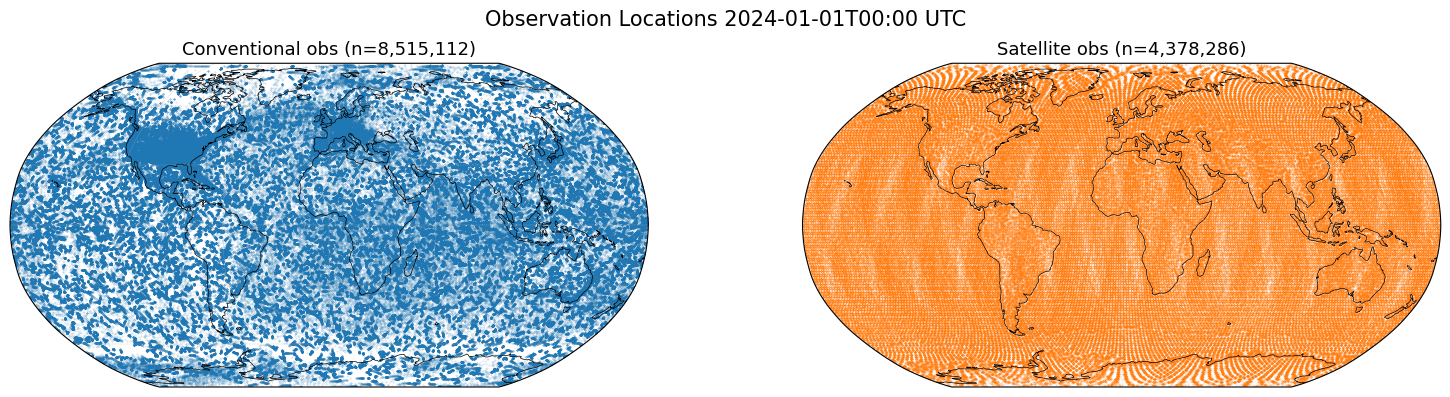

In [4]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

plt.close("all")
fig, axes = plt.subplots(
    1,
    2,
    subplot_kw={"projection": ccrs.Robinson()},
    figsize=(16, 4),
)

# การสังเกตแบบเดิมๆ
ax = axes[0]
ax.set_global()
ax.coastlines(linewidth=0.5)
ax.gridlines(linewidth=0.3, alpha=0.5)
ax.scatter(
    conv_df["lon"].values[::10],
    conv_df["lat"].values[::10],
    s=0.1,
    alpha=0.3,
    c="tab:blue",
    transform=ccrs.PlateCarree(),
)
ax.set_title(f"Conventional obs (n={len(conv_df):,})", fontsize=13)

# การสังเกตการณ์ด้วยดาวเทียม
ax = axes[1]
ax.set_global()
ax.coastlines(linewidth=0.5)
ax.gridlines(linewidth=0.3, alpha=0.5)
ax.scatter(
    sat_df["lon"].values[::10],
    sat_df["lat"].values[::10],
    s=0.1,
    alpha=0.3,
    c="tab:orange",
    transform=ccrs.PlateCarree(),
)
ax.set_title(f"Satellite obs (n={len(sat_df):,})", fontsize=13)
fig.suptitle(
    f"Observation Locations {str(analysis_time[0])[:16]} UTC",
    fontsize=15,
)
plt.tight_layout()
plt.savefig("outputs/22_healda_obs_locations.jpg", dpi=150)

สามารถเรียกโมเดล DA ได้โดยตรงสำหรับ inference แบบ statelessหรือผ่านทาง
:py:meth:`~earth2studio.models.da.HealDA.create_generator` สำหรับ stateful (วนซ้ำ)
การดูดซึม workflows  ที่นี่เราใช้การเรียกโดยตรง API เพื่อเรียกใช้โมเดล

HealDA ได้รับการออกแบบมาเพื่อทำงานร่วมกับหน้าต่างสังเกตชั่วโมง (-21, 3) จาก UFS
เก็บถาวรการเล่นซ้ำโดยใช้การสังเกตทั้งแบบธรรมดาและแบบดาวเทียม อย่างไรก็ตาม กฟผ
อินเทอร์เฟซโมเดลมีความยืดหยุ่นเพียงพอที่จะยอมรับกรอบเวลาและการสังเกตที่แตกต่างกัน
แหล่งที่มา ด้านล่างเราจะทดสอบการกำหนดค่าสามแบบ - แบบธรรมดาเท่านั้น ดาวเทียมเท่านั้น และ
รวมกันอย่างเหมาะสม - เพื่อแสดงให้เห็นผลกระทบแต่ละประเภทการสังเกตมีต่อการวิเคราะห์



In [5]:
torch.manual_seed(42)
result_both = model(conv_obs=conv_df, sat_obs=sat_df)
logger.info(f"Combined analysis shape: {result_both.shape}")

2026-04-25 13:31:38.703 | INFO     | __main__:<module>:3 - Combined analysis shape: (1, 74, 181, 360)


In [6]:
torch.manual_seed(42)
result_sat = model(sat_obs=sat_df)
logger.info(f"Sat-only analysis shape: {result_sat.shape}")

2026-04-25 13:31:40.870 | INFO     | __main__:<module>:3 - Sat-only analysis shape: (1, 74, 181, 360)


In [7]:
torch.manual_seed(42)
result_conv = model(conv_obs=conv_df)
logger.info(f"Conv-only analysis shape: {result_conv.shape}")

2026-04-25 13:31:43.681 | INFO     | __main__:<module>:3 - Conv-only analysis shape: (1, 74, 181, 360)


## การทำ Post-Processing
เนื่องจากเราโหลดโมเดลด้วย ``lat_lon=True`` เอาต์พุตจึงมีอยู่แล้ว
ตารางละติจูดเท่ากันทุกประการ ดังนั้นจึงไม่จำเป็นต้องทำการกริดใหม่ด้วยตนเอง
เปรียบเทียบทั้งสามรอบสำหรับอุณหภูมิพื้นผิว (t2m) และศักยภาพทางภูมิศาสตร์ 500 hPa
(z500). แต่ละแถวจะแสดงการกำหนดค่าการสังเกตที่แตกต่างกัน



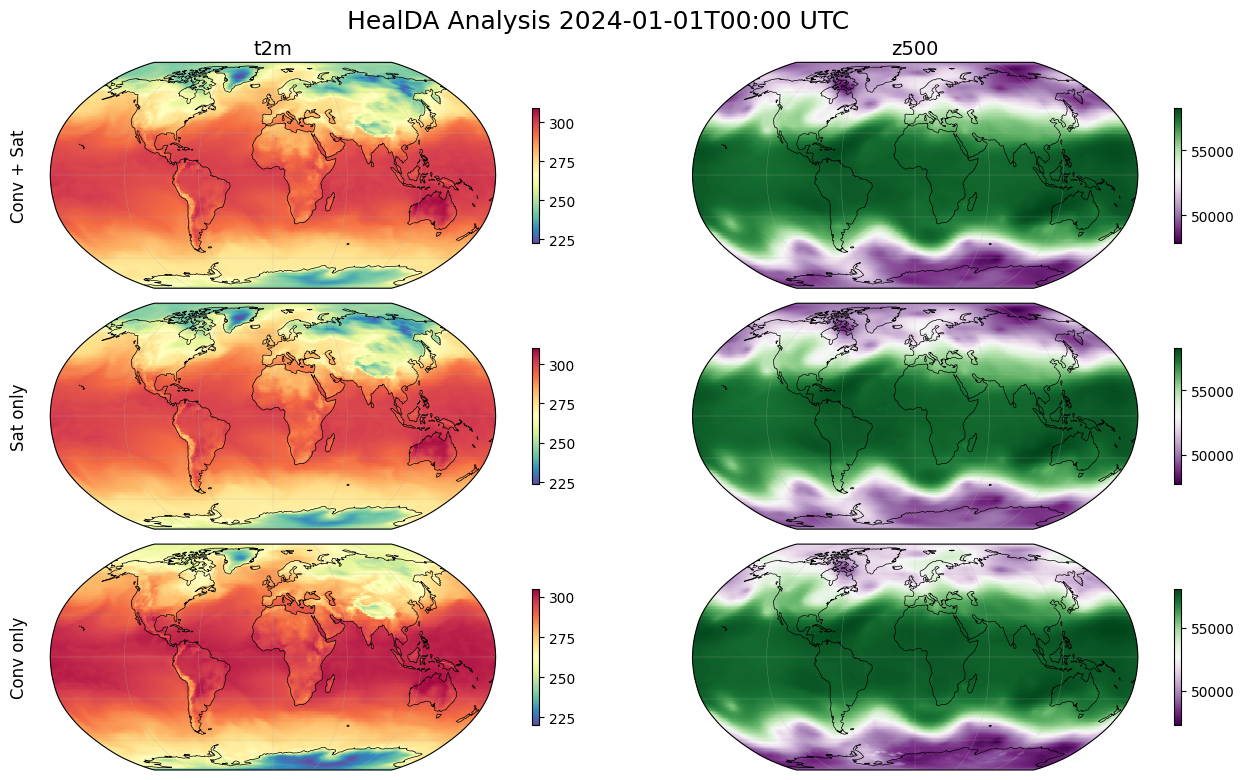

In [8]:
plt.close("all")
plot_vars = ["t2m", "z500"]
titles = ["Conv + Sat", "Sat only", "Conv only"]
results = [result_both, result_sat, result_conv]
projection = ccrs.Robinson()

fig, axes = plt.subplots(
    len(results),
    len(plot_vars),
    subplot_kw={"projection": projection},
    figsize=(14, 8),
)
fig.subplots_adjust(wspace=0.02, hspace=0.08, left=0.1, right=0.9)

lat = results[0].coords["lat"].values
lon = results[0].coords["lon"].values
cmaps = ["Spectral_r", "PRGn"]

for row, (title, da) in enumerate(zip(titles, results)):
    for col, var in enumerate(plot_vars):
        ax = axes[row, col]
        field = da.sel(variable=var).data[0].get()  # [nlat, nlon] cupy -> numpy
        im = ax.pcolormesh(
            lon,
            lat,
            field,
            transform=ccrs.PlateCarree(),
            cmap=cmaps[col],
        )
        ax.coastlines(linewidth=0.5)
        ax.gridlines(linewidth=0.3, alpha=0.5)
        fig.colorbar(im, ax=ax, shrink=0.6)
        if row == 0:
            ax.set_title(var, fontsize=14)
        if col == 0:
            ax.text(
                -0.05,
                0.5,
                title,
                fontsize=12,
                va="bottom",
                ha="center",
                rotation="vertical",
                rotation_mode="anchor",
                transform=ax.transAxes,
            )

fig.suptitle(f"HealDA Analysis {str(analysis_time[0])[:16]} UTC", fontsize=18, y=0.97)
plt.tight_layout()
plt.savefig("outputs/22_healda_analysis.jpg", dpi=150)

## HealDA กับ ERA5
ถัดไป ให้ดึงการวิเคราะห์ ERA5 ซ้ำที่ความละเอียด 0.25° จากไฟล์เก็บถาวร NCAR เพื่อเปรียบเทียบ
กับสนามหลอมรวม HealDA เอาต์พุตตัวแปร Earth2Studio มาตรฐาน
ชื่อเพื่อให้เราสามารถสืบค้น ERA5 ด้วยตัวระบุเดียวกันได้ เราคาดหวังการดำเนินการนั้น
ขาดแหล่งการสังเกตเพื่อแสดงข้อผิดพลาดที่ใหญ่กว่า ในขณะที่การดำเนินการแบบรวม
ให้ผลการทำนายทั่วโลกที่แม่นยำที่สุด



In [9]:
era5_ds = NCAR_ERA5()
era5_da = era5_ds(analysis_time, plot_vars)
era5_interp = era5_da.interp(lat=lat, lon=lon, method="nearest")

Fetching NCAR ERA5 data:   0%|          | 0/2 [00:00<?, ?it/s]

2026-04-25 13:31:57.791 | DEBUG    | earth2studio.data.ncar:fetch_array:402 - Fetching NCAR ERA5 variable: 2T in file s3://nsf-ncar-era5/e5.oper.an.sfc/202401/e5.oper.an.sfc.128_167_2t.ll025sc.2024010100_2024013123.nc


Fetching NCAR ERA5 data:   0%|          | 0/2 [00:00<?, ?it/s]

2026-04-25 13:31:58.632 | DEBUG    | earth2studio.data.ncar:fetch_array:402 - Fetching NCAR ERA5 variable: Z in file s3://nsf-ncar-era5/e5.oper.an.pl/202401/e5.oper.an.pl.128_129_z.ll025sc.2024010100_2024010123.nc


Fetching NCAR ERA5 data: 100%|██████████| 2/2 [08:31<00:00, 255.56s/it]


In [10]:
diff_titles = ["Conv+Sat - ERA5", "Sat - ERA5", "Conv - ERA5"]
diff_results = [result_both, result_sat, result_conv]
for title, da_pred in zip(diff_titles, diff_results):
    for var in plot_vars:
        field_pred = da_pred.sel(variable=var).data[0]
        if hasattr(field_pred, "get"):
            field_pred = field_pred.get()
        field_era5 = era5_interp.sel(variable=var).data[0]
        mae = float(np.abs(field_pred - field_era5).mean())
        logger.info(f"{title} | {var} MAE: {mae:.4f}")

2026-04-25 13:40:28.949 | INFO     | __main__:<module>:10 - Conv+Sat - ERA5 | t2m MAE: 0.7997
2026-04-25 13:40:28.950 | INFO     | __main__:<module>:10 - Conv+Sat - ERA5 | z500 MAE: 51.1919
2026-04-25 13:40:28.951 | INFO     | __main__:<module>:10 - Sat - ERA5 | t2m MAE: 0.8489
2026-04-25 13:40:28.951 | INFO     | __main__:<module>:10 - Sat - ERA5 | z500 MAE: 164.9830
2026-04-25 13:40:28.952 | INFO     | __main__:<module>:10 - Conv - ERA5 | t2m MAE: 4.3315
2026-04-25 13:40:28.952 | INFO     | __main__:<module>:10 - Conv - ERA5 | z500 MAE: 570.9339


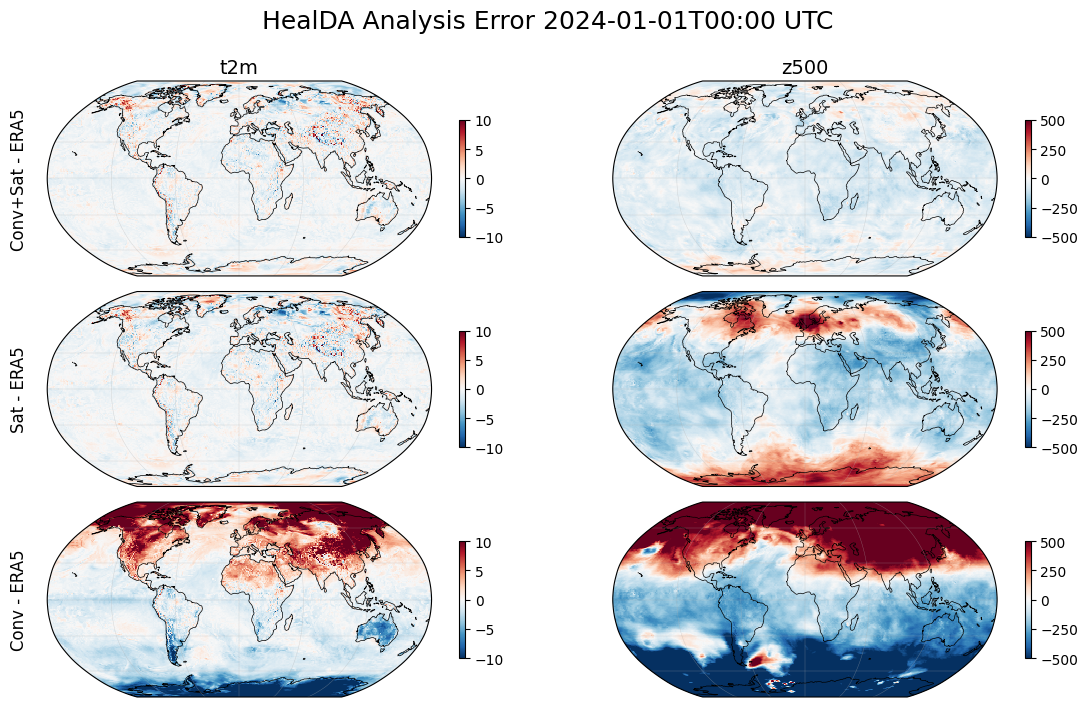

In [11]:
plt.close("all")

diff_ranges = {"t2m": (-10, 10), "z500": (-500, 500)}
fig, axes = plt.subplots(
    len(diff_results),
    len(plot_vars),
    subplot_kw={"projection": projection},
    figsize=(14, 8),
)
fig.subplots_adjust(wspace=0.02, hspace=0.08, left=0.1, right=0.9)

for row, (title, da_pred) in enumerate(zip(diff_titles, diff_results)):
    for col, var in enumerate(plot_vars):
        ax = axes[row, col]
        field_pred = (
            da_pred.sel(variable=var).data[0].get()
        )  # [nlat, nlon] cupy -> numpy
        field_era5 = era5_interp.sel(variable=var).data[0]  # [นลัท, นลอน]
        diff = field_pred - field_era5
        im = ax.pcolormesh(
            lon,
            lat,
            diff,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=diff_ranges[var][0],
            vmax=diff_ranges[var][1],
        )
        ax.coastlines(linewidth=0.5)
        ax.gridlines(linewidth=0.3, alpha=0.5)
        fig.colorbar(im, ax=ax, shrink=0.6)
        if row == 0:
            ax.set_title(var, fontsize=14)
        if col == 0:
            bbox = ax.get_position()
            ax.text(
                -0.05,
                0.5,
                title,
                fontsize=12,
                va="bottom",
                ha="center",
                rotation="vertical",
                rotation_mode="anchor",
                transform=ax.transAxes,
            )

fig.suptitle(
    f"HealDA Analysis Error {str(analysis_time[0])[:16]} UTC",
    fontsize=18,
    y=0.97,
)
plt.savefig("outputs/22_healda_differences.jpg", dpi=150, bbox_inches="tight")